Data loaded successfully!
Shape: (150, 6)

META INFORMATION
Total samples: 150
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Class distribution:
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: species, dtype: int64
Feature ranges:
  Sepal Length: 4.3 - 7.9 cm
  Sepal Width: 2.0 - 4.4 cm
  Petal Length: 1.0 - 6.9 cm
  Petal Width: 0.1 - 2.5 cm


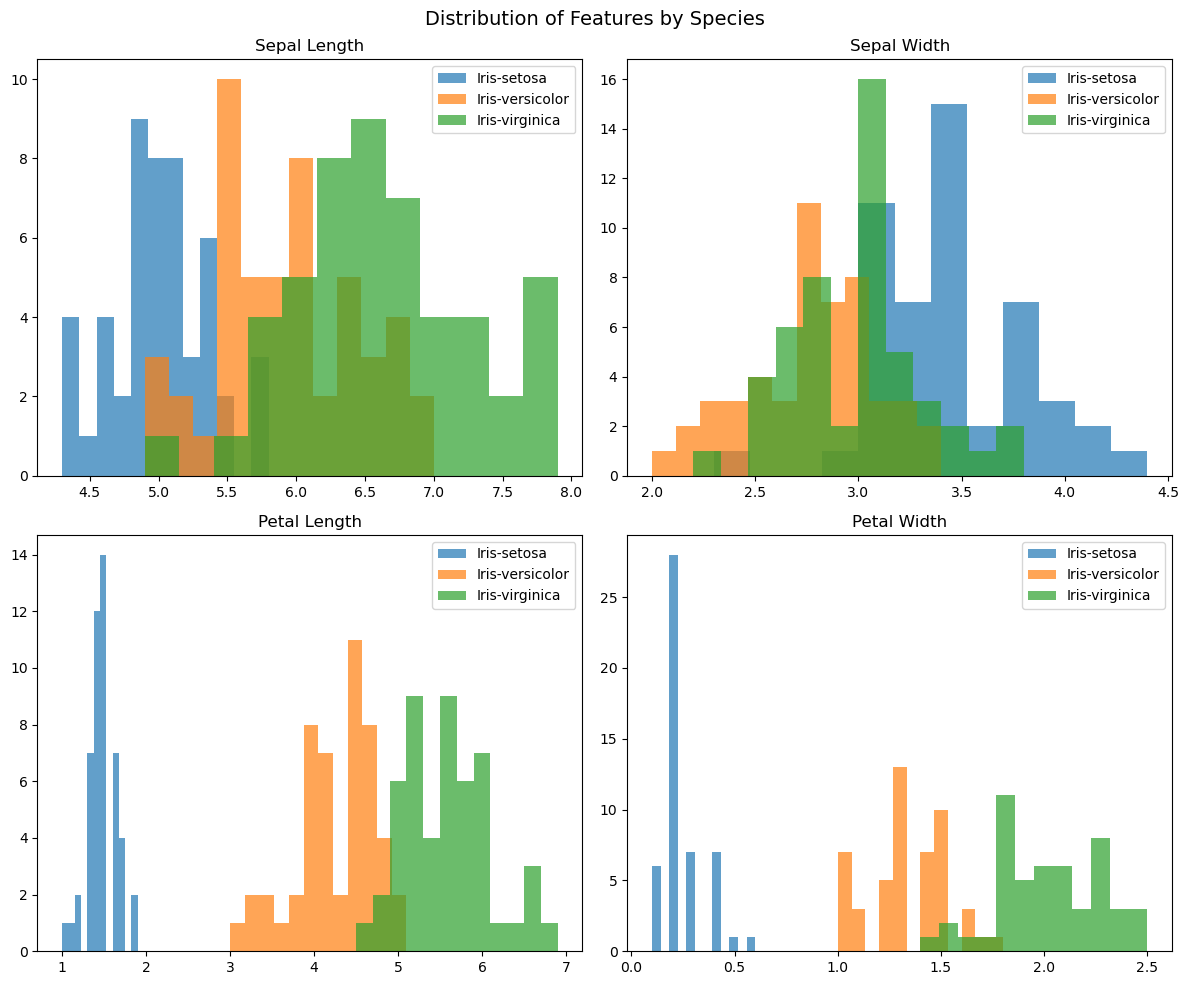

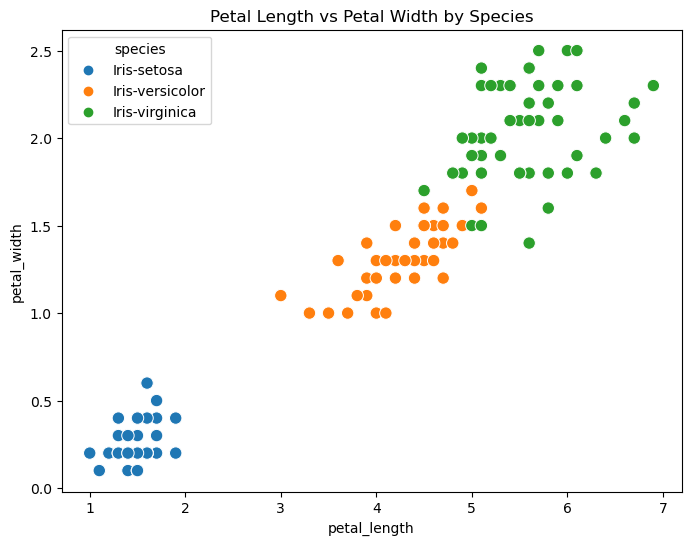


LOGISTIC REGRESSION RESULTS
Test Accuracy: 0.9111 (91.11%)


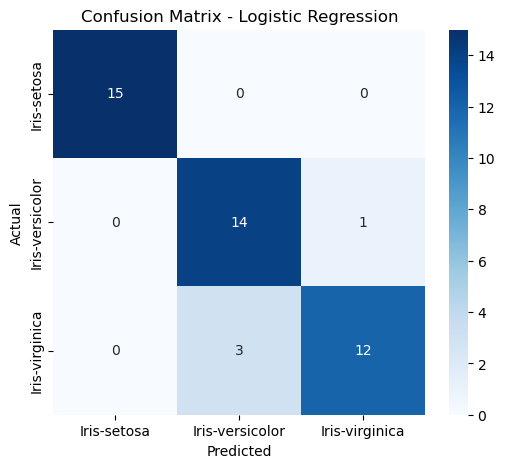


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.87        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45


KNN CLASSIFICATION (k = 2 to 20)
Best k value: 9
Best accuracy: 0.9556 (95.56%)


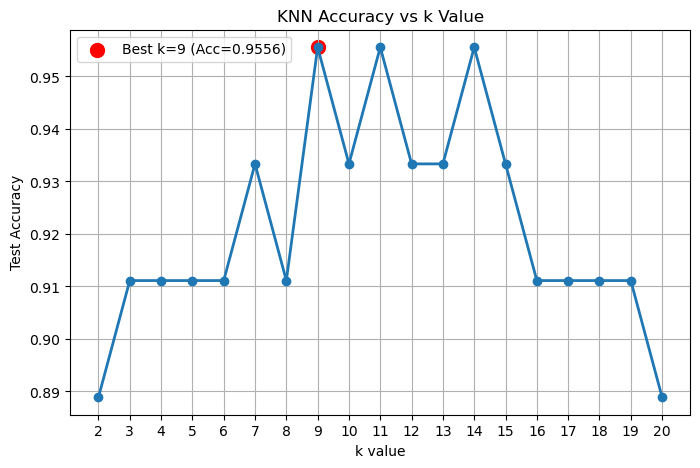

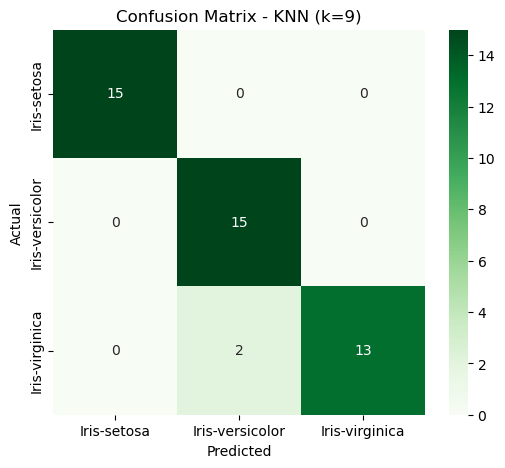


Classification Report - KNN (k=9):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45


SUMMARY
Logistic Regression Accuracy: 0.9111
Accuracy: 91.11%
KNN (k=9) Accuracy: 0.9556
Best model: KNN


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('iris.csv')
print("Data loaded successfully!")
print(f"Shape: {df.shape}")

# Exercise 1.1: Meta Information 
print("\n" + "="*50)
print("META INFORMATION")
print("="*50)
print(f"Total samples: {df.shape[0]}")
print(f"Features: {df.columns[1:-1].tolist()}")
print(f"Classes: {df['species'].unique().tolist()}")
print(f"Class distribution:\n{df['species'].value_counts()}")
print(f"Feature ranges:")
print(f"  Sepal Length: {df['sepal_length'].min():.1f} - {df['sepal_length'].max():.1f} cm")
print(f"  Sepal Width: {df['sepal_width'].min():.1f} - {df['sepal_width'].max():.1f} cm")
print(f"  Petal Length: {df['petal_length'].min():.1f} - {df['petal_length'].max():.1f} cm")
print(f"  Petal Width: {df['petal_width'].min():.1f} - {df['petal_width'].max():.1f} cm")

# Exercise 1.2: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        axes[row, col].hist(subset[feature], alpha=0.7, label=species, bins=12)
    axes[row, col].set_title(f'{feature.replace("_", " ").title()}')
    axes[row, col].legend()

plt.suptitle('Distribution of Features by Species', fontsize=14)
plt.tight_layout()
plt.show()

# Scatter plot: Petal Length vs Width (most discriminative)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', s=80)
plt.title('Petal Length vs Petal Width by Species')
plt.show()


#  Exercise 1.3: Logistic Regression 
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Split 70-30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=200)
log_reg.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = log_reg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


# Exercise 1.4: Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['species'].unique(),
            yticklabels=df['species'].unique())
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# KNN for k = 2 to 20
print("\n" + "="*50)
print("KNN CLASSIFICATION (k = 2 to 20)")
print("="*50)

k_values = range(2, 21)
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    test_accuracies.append(accuracy_score(y_test, y_pred_knn))

# Find best k
best_k = k_values[np.argmax(test_accuracies)]
best_acc = max(test_accuracies)

print(f"Best k value: {best_k}")
print(f"Best accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

# Plot k vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, test_accuracies, marker='o', linewidth=2)
plt.scatter(best_k, best_acc, color='red', s=100, 
            label=f'Best k={best_k} (Acc={best_acc:.4f})')
plt.xlabel('k value')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k Value')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

# knn 
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=df['species'].unique(),
            yticklabels=df['species'].unique())
plt.title(f'Confusion Matrix - KNN (k={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"\nClassification Report - KNN (k={best_k}):")
print(classification_report(y_test, y_pred_knn))


#  Summary Comparison
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"KNN (k={best_k}) Accuracy: {best_acc:.4f}")
print(f"Best model: {'Logistic Regression' if accuracy >= best_acc else 'KNN'}")